# Updatining Predictions for Unlabeled Trials

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import deeplabcut
import DLCsupport as dlcs
import deeplabcut as dlc
import matplotlib.pyplot as plt
from importlib.util import spec_from_file_location, module_from_spec
import glob
import xrommtools as xt
import re
import shutil

from PIL import Image
from PostAnalysis_review import find_darkest_pixel, collect_images



module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\data-converters.py"
spec = spec_from_file_location("dc", module_path)
dc = module_from_spec(spec)
spec.loader.exec_module(dc)

module_path = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py"
spec = spec_from_file_location("xt", module_path)
xt = module_from_spec(spec)
spec.loader.exec_module(xt)

In [15]:

def snap_combined_predictions_to_dark_pixels(
    pred_csv,
    cam1_dir,
    cam2_dir,
    out_csv=None,
    window_size=5,
):
    """Snap each predicted keypoint to the nearest dark pixel in the matching frame image."""
    pred_csv = Path(pred_csv)
    cam1_dir = Path(cam1_dir)
    cam2_dir = Path(cam2_dir)

    df = pd.read_csv(pred_csv)
    out = df.copy()

    images_by_cam = {
        "cam1": collect_images(cam1_dir),
        "cam2": collect_images(cam2_dir),
    }

    # Parse columns like bodypart_cam1_X / bodypart_cam2_Y
    col_pattern = re.compile(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$")
    col_map = {}
    bodyparts = set()
    for col in out.columns:
        match = col_pattern.match(str(col))
        if match is None:
            continue
        bp = str(match.group("bodypart"))
        cam = f"cam{match.group('cam')}"
        coord = str(match.group("coord")).upper()
        col_map[(bp, cam, coord)] = col
        bodyparts.add(bp)

    if not bodyparts:
        raise ValueError(
            "No prediction columns found in combined format (expected bodypart_cam1_X style columns)."
        )

    bodyparts = sorted(bodyparts)

    n_frames = len(out)
    print(f"Snapping {len(bodyparts)} bodyparts across {n_frames} frames...")

    for frame_pos in range(n_frames):
        if frame_pos % 100 == 0:
            print(f"  frame {frame_pos}/{n_frames - 1}")

        for cam in ("cam1", "cam2"):
            images = images_by_cam[cam]
            if not (0 <= frame_pos < len(images)):
                continue

            with Image.open(images[frame_pos]) as image_file:
                gray_img = np.asarray(image_file.convert("L"))

            occupied_pixels = set()

            for bp in bodyparts:
                xcol = col_map.get((bp, cam, "X"))
                ycol = col_map.get((bp, cam, "Y"))
                if xcol is None or ycol is None:
                    continue

                x_val = pd.to_numeric(out.at[frame_pos, xcol], errors="coerce")
                y_val = pd.to_numeric(out.at[frame_pos, ycol], errors="coerce")
                if not (np.isfinite(x_val) and np.isfinite(y_val)):
                    continue

                rr, cc = find_darkest_pixel(
                    gray_img,
                    row=float(y_val),
                    col=float(x_val),
                    occupied=occupied_pixels,
                    window_size=int(window_size),
                )

                out.at[frame_pos, xcol] = float(cc)
                out.at[frame_pos, ycol] = float(rr)

    if out_csv is None:
        out_csv = pred_csv.with_name(f"{pred_csv.stem}_snapped_dark.csv")
    else:
        out_csv = Path(out_csv)

    out.to_csv(out_csv, index=False)
    print(f"Saved snapped predictions: {out_csv}")
    return out_csv, out


# snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
#     pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints.csv",
#     cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
#     cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
#     # out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
#     window_size=4,
# )

# snapped_df.head()

### Trial 8

In [14]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingDat

In [15]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\config.yaml from 'Tyler_Finetune' to 'Tyler'


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial8\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-12\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial8\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-12\\labeled-data\\For_Test_20_Eval17_Dino_n400_s125']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyle

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-tr

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

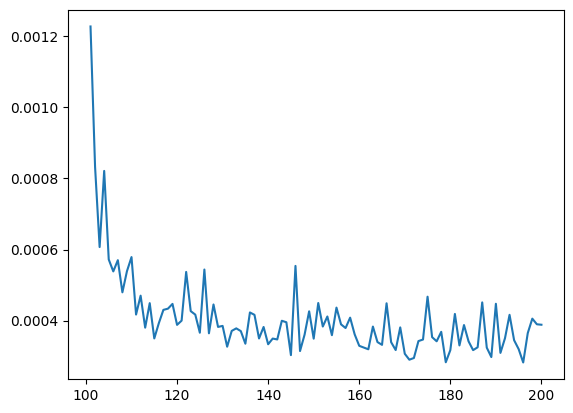

In [16]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [19]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino",
    batchsize=16
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-12\dlc-models-pytorch\iteration-0\CanariJun12-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJun12shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.23it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.26it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\active_updates\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariJun12shuffle1_snapshot_200'

In [3]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_Trial8\dino\Cam1DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_Trial8\dino\Cam2DLC_Resnet50_CanariJun12shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8")

### Snapping to the nearest Darkstar!
Across the imagestack/predictions

In [6]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial8\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

snapped_df.head()

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

,Cranium_Left_Anterior_cam1_X,Cranium_Left_Anterior_cam1_Y,Cranium_Left_Anterior_cam2_X,Cranium_Left_Anterior_cam2_Y,Cranium_Left_Middle_cam1_X,Cranium_Left_Middle_cam1_Y,Cranium_Left_Middle_cam2_X,Cranium_Left_Middle_cam2_Y,Cranium_Right_Middle_cam1_X,Cranium_Right_Middle_cam1_Y,...,Pelvis_Right_Superior_cam2_X,Pelvis_Right_Superior_cam2_Y,Pelvis_Left_Superior_cam1_X,Pelvis_Left_Superior_cam1_Y,Pelvis_Left_Superior_cam2_X,Pelvis_Left_Superior_cam2_Y,Pelvis_Left_Inferior_cam1_X,Pelvis_Left_Inferior_cam1_Y,Pelvis_Left_Inferior_cam2_X,Pelvis_Left_Inferior_cam2_Y
0,334.0,213.0,410.0,235.0,341.0,208.0,447.0,231.0,306.0,219.0,...,573.0,479.0,307.0,427.0,602.0,480.0,309.0,430.0,602.0,481.0
1,334.0,212.0,410.0,234.0,340.0,208.0,447.0,231.0,306.0,219.0,...,573.0,479.0,306.0,427.0,602.0,480.0,309.0,430.0,603.0,481.0
2,335.0,212.0,411.0,234.0,339.0,208.0,449.0,230.0,306.0,219.0,...,573.0,479.0,307.0,427.0,601.0,481.0,309.0,430.0,604.0,483.0
3,335.0,212.0,411.0,234.0,339.0,208.0,449.0,230.0,307.0,220.0,...,573.0,479.0,306.0,427.0,601.0,479.0,306.0,428.0,604.0,482.0
4,336.0,212.0,413.0,233.0,338.0,208.0,451.0,230.0,307.0,220.0,...,574.0,481.0,306.0,427.0,602.0,479.0,306.0,428.0,602.0,482.0


### Trial 2
notice a mismatch in video frame count...

In [7]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

In [4]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="UpdateModelForTrial2",
    experimenter="Tyler",
    nframes=25,
    frame_selection_seed=42,
)

Using trial folders: ['ModelTraining']
Extracting camera 1 trial images and 2D points...
Extracting camera 2 trial images and 2D points...
...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset


In [5]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\config.yaml from 'Tyler_Finetune' to 'Tyler'


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial2\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-15\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial2\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-15\\labeled-data\\UpdateModelForTrial2']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-20

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-tr

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

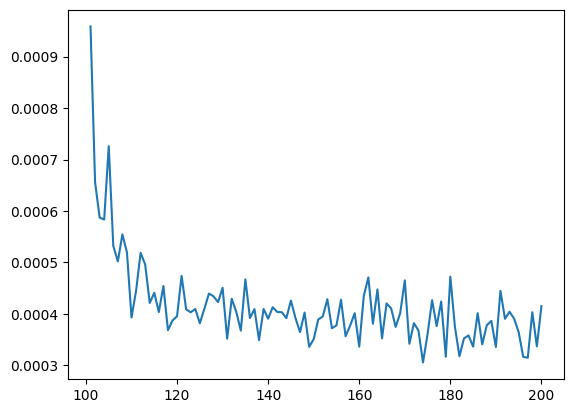

In [6]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")

In [10]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino",
    batchsize=16
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJun15shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.23it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2.avi
Video metadata: 
  Overall # of frames:    5285
  Duration of video [s]:  10.57
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 5285/5285 [02:29<00:00, 35.29it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariJun15shuffle1_snapshot_200'

In [11]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2")

c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:322: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Cranium_Left_Anterior_cam1_X', 'Cranium_Left_Anterior_cam1_Y',
       'Cranium_Left_Anterior_cam2_X', 'Cranium_Left_Anterior_cam2_Y',
       'Cranium_Left_Middle_cam1_X', 'Cranium_Left_Middle_cam1_Y',
       'Cranium_Left_Middle_cam2_X', 'Cranium_Left_Middle_cam2_Y',
       'Cranium_Right_Middle_cam1_X', 'Cranium_Right_Middle_cam1_Y',
       'Cranium_Right_Middle_cam2_X', 'Cranium_Right_Middle_cam2_Y',
       'Cranium_Right_Posterior_cam1_X', 'Cranium_Right_Posterior_cam1_Y',
       'Cranium_Right_Posterior_cam2_X', 'Cranium_Right_Posterior_cam2_Y',
       'Beak_Mandible_Left_Posterior_cam1_X',
       'Beak_Mandible_Left_Posterior_cam1_Y',
       'Beak_Mandible_Left_Posterior_cam2_X',
       'Beak_Mand

In [12]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

### Trial 3
Opens mouth wide!

In [13]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

In [14]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="For_Test_20_Eval17_Dino_n400_s125",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingDat

In [15]:
import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\config.yaml from 'Tyler_Finetune' to 'Tyler'
INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial3\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-15\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial3\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-15\\labeled-data\\For_Test_20_Eval17_Dino_n400_s125']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyle

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-tr

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

Text(0, 0.5, 'Training Loss')

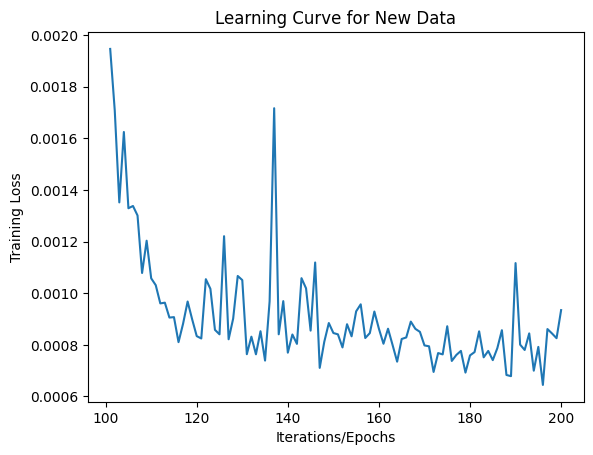

In [31]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\ActiveUpdates\Trial3\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")
plt.title("Learning Curve for New Data")
plt.xlabel("Iterations/Epochs")
plt.ylabel("Training Loss")

In [ ]:
dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino",
    batchsize=16
)

Creating the output folder C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-15\dlc-models-pytorch\iteration-0\CanariJun15-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJun15shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:51<00:00, 35.08it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.11it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial2\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_CanariJun15shuffle1_snapshot_200'

In [19]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam1DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\active_updates\dino\Cam2DLC_Resnet50_CanariJun15shuffle1_snapshot_200.csv", 
    "ModelUpdateMonday", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3")

In [20]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\ModelUpdateMonday-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial3\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

### Trial 4


In [4]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial4\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

### Trial 5


In [6]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

In [19]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino"
)

models = src_trial / "ModelsToTune"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Canari",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"DavidBowie": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = src_trial / "data/corrections_autosave.csv" 
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="UpdateTrial5-30",
    experimenter="Tyler",
    nframes=30,
    frame_selection_seed=42,
)

import time
snapshot_path = (
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\DavidBowie\Model519\n400_T17\Canari-Tyler-2026-05-22\dlc-models-pytorch\iteration-0\CanariMay22-trainset95shuffle1\train\snapshot-100.pt"
)
t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
    snapshot_path=snapshot_path
)
elapsed = time.perf_counter() - t0
print(elapsed)

Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingDat

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\config.yaml from 'Tyler_Finetune' to 'Tyler'
INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial5\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-17\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\DavidBowie\\Trial5\\active_updates\\dino\\ModelsToTune\\Canari-Tyler_Finetune-2026-06-17\\labeled-data\\UpdateTrial5-30']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNH

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models-pytorch\iteration-0\CanariJun17-tr

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models-pytorch\iteration-0\CanariJun17-trainset95shuffle1\train\snapshot-200.pt
Using scorer: DLC_Resnet50_CanariJun17shuffle1_snapshot_200
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:51<00:00, 34.94it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam2DLC_Resnet50_CanariJun17shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam2DLC_Resnet50_CanariJun17shuffle1_snapshot_200_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:51<00:00, 35.01it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam1DLC_Resnet50_CanariJun17shuffle1_snapshot_200.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam1DLC_Resnet50_CanariJun17shuffle1_snapshot_200_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000

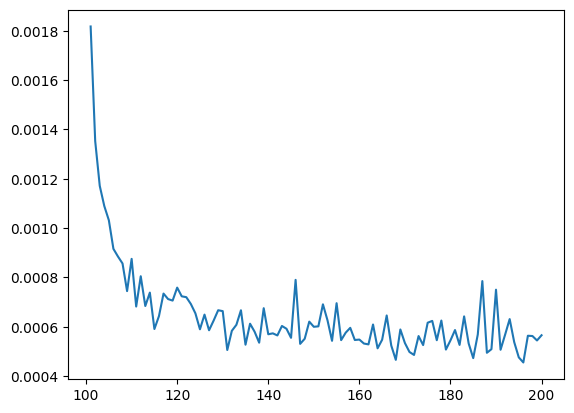

In [20]:
# plot learning stats
learning_stats = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\ModelsToTune\Canari-Tyler_Finetune-2026-06-17\dlc-models-pytorch\iteration-0\CanariJun17-trainset95shuffle1\train\learning_stats.csv")
learning_stats.head()
plt.plot(learning_stats["step"], learning_stats["losses/train.total_loss"], label="train_loss")
plt.show()

dlc.analyze_videos(
    combined_config,
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino",
    batchsize=16
)

xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam1DLC_Resnet50_CanariJun17shuffle1_snapshot_200.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\active_updates\dino\Cam2DLC_Resnet50_CanariJun17shuffle1_snapshot_200.csv", 
    "ModelUpdate", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5")

snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\ModelUpdate-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial5\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

### Trial 6


In [7]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial6\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

### Trial 7

In [8]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial7\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 21 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

### Trial 9

n'existe pas

In [ ]:
snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\NoUpdateModel-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial9\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

# Tulio Training First Model

Selected data from dino method first from the whole set to train first model (chose 100 frames)

In [2]:
src_trial = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining"
)

models = src_trial / "Model"
models.mkdir(exist_ok=True)
# 1) Ensure we have a real DLC project config.yaml to write labeled-data into
# Replace dummy_video with any existing video file you already use for project init.
combined_config = dlcs.create_combined_project_if_missing(
    task="Tulio",
    experimenter="Tyler_Finetune",
    combined_project_root=models,
    dummy_video=Path(
        r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\Cam1.avi"
    ),
)

# edit the config.yaml to add our 2D points CSV as a scorer with appropriate bodyparts and skeleton info
bodyparts_apply_df = dlcs.apply_bird_bodyparts_to_configs(
        {"Tulio": [combined_config]},
        strict=True,
    )

# 2) Build a clean trial folder for xma_to_dlc

clean_trial = src_trial / "ModelTraining"
clean_trial.mkdir(parents=True, exist_ok=True)

# Copy camera folders
for cam_folder in ["Cam1", "Cam2"]:
    src = src_trial / cam_folder
    dst = clean_trial / cam_folder
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

# Pick truth CSV and keep only coordinate columns
truth_csv = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\LabeledBodyPartsCoordinatesSubset.csv"
df = pd.read_csv(truth_csv)

coord_cols = [c for c in df.columns if re.search(r"_cam[12]_[XY]$", c)]
clean_df = df[coord_cols]

# Name contains 2Dpoints so xrommtools picks it first
clean_points_csv = clean_trial / "UpdatedLabels-2Dpoints.csv"
clean_df.to_csv(clean_points_csv, index=False)

# 3) Build dataset from cleaned trial
dlcs.build_combined_dataset(
    combined_config=combined_config,      # real config.yaml path
    data_path=clean_trial,                # folder containing csv + Cam1 + Cam2
    dataset_name="TulioDiverseData100",
    experimenter="Tyler",
    nframes=100,
    frame_selection_seed=42,
)

Using trial folders: ['ModelTraining']
Extracting camera 1 trial images and 2D points...
Extracting camera 2 trial images and 2D points...
...done.
Training data extracted to projectpath/labeled-data. Now use deeplabcut.create_training_dataset


In [3]:
import time

t0 = time.perf_counter()
dlcs.create_and_train(
    config_path=combined_config,
    epochs=100,
)
elapsed = time.perf_counter() - t0
print(elapsed)

Updated scorer in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml from 'Tyler_Finetune' to 'Tyler'


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated).
Annotation data was not found by splitting video paths (from config['video_sets']). An alternative route is taken...
The following folders were found: ['C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\Tulio\\SmallSetTraining\\Model\\Tulio-Tyler_Finetune-2026-06-16\\labeled-data\\Cam1', 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut2\\Tulio\\SmallSetTraining\\Model\\Tulio-Tyler_Finetune-2026-06-16\\labeled-data\\TulioDiverseData100']
C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\labeled-data\Cam1\CollectedData_Tyler.h5  not found (perhaps not annotated)


Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16
  pose_config_path: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\pytorch_config.yaml
  bodypart

FileNotFoundError: No snapshots found under pattern: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\*\train\snapshots\snapshot-*.pt

### Trial 1

In [23]:
config_path_tulio = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml"

In [26]:
def predict_trial_from_jpg_stacks(
    config_path,
    bird,
    trial_number,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
):
    """
    End-to-end trial prediction pipeline:
    1) Convert Cam1/Cam2 JPG stacks to AVI
    2) Run DLC prediction from config.yaml
    3) Convert DLC CSV outputs to XMA combined 2D points CSV
    4) Snap combined predictions to nearest dark pixels

    Parameters
    ----------
    config_path : str or Path
        Path to a DeepLabCut config.yaml file.
    bird : str
        Bird folder name under ProcessingData (e.g., "Tulio", "DavidBowie").
    trial_number : int or str
        Trial number used to build Trial{n} (e.g., 1 -> Trial1).
    base_processing_dir : Path
        Root folder containing bird trial data.
    fps : int
        FPS used to build AVI files from JPG stacks.
    batchsize : int
        Batch size used by dlc.analyze_videos.
    save_as_csv : bool
        Whether to save predictions as CSV.
    xma_base_name : str
        Prefix used by xt.dlc_to_xma for output naming.
    snap_window_size : int
        Search window size used when snapping to dark pixels.
    """
    config_path = Path(config_path)
    trial_dir = Path(base_processing_dir) / str(bird) / f"Trial{trial_number}"

    cam1_dir = trial_dir / "Cam1"
    cam2_dir = trial_dir / "Cam2"
    cam1_avi = trial_dir / "Cam1.avi"
    cam2_avi = trial_dir / "Cam2.avi"

    if not cam1_dir.exists() or not cam2_dir.exists():
        raise FileNotFoundError(
            f"Expected Cam1/Cam2 folders in {trial_dir}, but one or both are missing."
        )
    print("Converting Cine Image stacks to AVI videos")
    # 1) Build videos from image stacks
    dc.jpg_stack_to_avi(input_folder=cam1_dir, output_path=cam1_avi, fps=int(fps))
    dc.jpg_stack_to_avi(input_folder=cam2_dir, output_path=cam2_avi, fps=int(fps))
    print("Now To Analyze the videos with existing model!")
    # 2) Run prediction using the provided DLC config
    dlc.analyze_videos(
        str(config_path),
        [str(cam1_avi), str(cam2_avi)],
        save_as_csv=bool(save_as_csv),
        destfolder=str(trial_dir),
        batchsize=int(batchsize),
    )

    # 3) Find newest DLC CSV outputs and convert to XMA combined format
    cam1_candidates = sorted(
        trial_dir.glob("Cam1DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )
    cam2_candidates = sorted(
        trial_dir.glob("Cam2DLC*.csv"),
        key=lambda path: path.stat().st_mtime,
    )

    if not cam1_candidates or not cam2_candidates:
        raise FileNotFoundError(
            f"Could not find Cam1DLC*.csv / Cam2DLC*.csv in {trial_dir} after prediction."
        )

    cam1_dlc_csv = cam1_candidates[-1]
    cam2_dlc_csv = cam2_candidates[-1]
    print("Converting predictions to XMA format")
    xt.dlc_to_xma(
        str(cam1_dlc_csv),
        str(cam2_dlc_csv),
        str(xma_base_name),
        str(trial_dir),
    )

    # 4) Snap the generated combined predictions to dark pixels
    pred_csv = trial_dir / f"{xma_base_name}-Predicted2DPoints.csv"
    if not pred_csv.exists():
        pred_candidates = sorted(
            trial_dir.glob("*-Predicted2DPoints.csv"),
            key=lambda path: path.stat().st_mtime,
        )
        if not pred_candidates:
            raise FileNotFoundError(
                f"Could not find a *-Predicted2DPoints.csv in {trial_dir} after dlc_to_xma."
            )
        pred_csv = pred_candidates[-1]
    print("Snapping predictions to darkest Pixel")
    snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
        pred_csv=str(pred_csv),
        cam1_dir=str(cam1_dir),
        cam2_dir=str(cam2_dir),
        window_size=int(snap_window_size),
    )

    print(f"Finished full pipeline for {bird} Trial{trial_number} -> {trial_dir}")
    return {
        "trial_dir": trial_dir,
        "cam1_avi": cam1_avi,
        "cam2_avi": cam2_avi,
        "cam1_dlc_csv": cam1_dlc_csv,
        "cam2_dlc_csv": cam2_dlc_csv,
        "pred_csv": pred_csv,
        "snapped_csv": Path(snapped_csv),
        "snapped_df": snapped_df,
    }


# Example usage (Trial 1)
# result = predict_trial_from_jpg_stacks(
#     config_path=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml",
#     bird="Tulio",
#     trial_number=1,
# )

In [8]:
dc.jpg_stack_to_avi(
    input_folder=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1"),
    output_path=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1.avi"),
    fps=500)


dc.jpg_stack_to_avi(
    input_folder=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2"),
    output_path=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2.avi"),
    fps=500)

{'output_path': 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\ProcessingData\\Tulio\\Trial1\\Cam2.avi',
 'frames_written': 6001,
 'fps': 500,
 'codec': 'MJPG',
 'width': 768,
 'height': 768}

In [9]:
dlc.analyze_videos(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\config.yaml",
    [str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1.avi")), str(Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial1\Cam2.avi"))],
    save_as_csv=True,
    destfolder=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1",
    batchsize=16
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\Trial1\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.24it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.24it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_TulioJun16shuffle1_snapshot_100'

In [16]:
xt.dlc_to_xma(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv", 
    "ModelPredicted", 
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1")

snapped_csv, snapped_df = snap_combined_predictions_to_dark_pixels(
    pred_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\ModelPredicted-Predicted2DPoints.csv",
    cam1_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam1",
    cam2_dir=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial1\Cam2",
    #out_csv=r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\DavidBowie\active_updates_trial8\ModelUpdate-Predicted2DPoints-snapped-dark.csv",
    window_size=4,
)

Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/6000
  frame 1800/6000
  frame 1900/6000
  frame 2000/6000
  frame 2100/6000
  frame 2200/6000
  frame 2300/6000
  frame 2400/6000
  frame 2500/6000
  frame 2600/6000
  frame 2700/6000
  frame 2800/6000
  frame 2900/6000
  frame 3000/6000
  frame 3100/6000
  frame 3200/6000
  frame 3300/6000
  frame 3400/6000
  frame 3500/6000
  frame 3600/6000
  frame 3700/6000
  frame 3800/6000
  frame 3900/6000
  frame 4000/6000
  frame 4100/6000
  frame 4200/6000
  frame 4300/6000
  frame 4400/6000
  frame 4500/6000
  frame 4600/6000
  frame 4700/6000
  frame 4800/6000
  frame 4900/6000
  frame 5000/6000
  frame 5100/6000
  frame 5200/6000
  frame 5300/6

In [24]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    3,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:50<00:00, 35.20it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [02:54<00:00, 34.39it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial3\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/60

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial3/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Salle-Cin

In [25]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    4,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.23it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.24it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial4\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300/6000
  frame 1400/6000
  frame 1500/6000
  frame 1600/6000
  frame 1700/60

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial4/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Salle-Cin

In [27]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    5,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.22it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.24it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial5\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format
Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial5/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Salle-Cin

In [28]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    6,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.29it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam2.avi
Video metadata: 
  Overall # of frames:    7844
  Duration of video [s]:  15.69
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 7844/7844 [03:56<00:00, 33.19it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial6\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format


C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\xrommtools.py:322: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['CraniumRightPosterior_cam1_X', 'CraniumRightPosterior_cam1_Y',
       'CraniumRightPosterior_cam2_X', 'CraniumRightPosterior_cam2_Y',
       'CraniumLeftPosterior_cam1_X', 'CraniumLeftPosterior_cam1_Y',
       'CraniumLeftPosterior_cam2_X', 'CraniumLeftPosterior_cam2_Y',
       'CraniumRightMiddle_cam1_X', 'CraniumRightMiddle_cam1_Y',
       'CraniumRightMiddle_cam2_X', 'CraniumRightMiddle_cam2_Y',
       'CraniumRightAnterior_cam1_X', 'CraniumRightAnterior_cam1_Y',
       'CraniumRightAnterior_cam2_X', 'CraniumRightAnterior_cam2_Y',
       'CraniumLeftAnterior_cam1_X', 'CraniumLeftAnterior_cam1_Y',
       'CraniumLeftAnterior_cam2_X', 'CraniumLeftAnterior_cam2_Y',
       'MaxillaRightPosterior_cam1_X'

Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 7844 frames...
  frame 0/7843
  frame 100/7843
  frame 200/7843
  frame 300/7843
  frame 400/7843
  frame 500/7843
  frame 600/7843
  frame 700/7843
  frame 800/7843
  frame 900/7843
  frame 1000/7843
  frame 1100/7843
  frame 1200/7843
  frame 1300/7843
  frame 1400/7843
  frame 1500/7843
  frame 1600/7843
  frame 1700/7843
  frame 1800/7843
  frame 1900/7843
  frame 2000/7843
  frame 2100/7843
  frame 2200/7843
  frame 2300/7843
  frame 2400/7843
  frame 2500/7843
  frame 2600/7843
  frame 2700/7843
  frame 2800/7843
  frame 2900/7843
  frame 3000/7843
  frame 3100/7843
  frame 3200/7843
  frame 3300/7843
  frame 3400/7843
  frame 3500/7843
  frame 3600/7843
  frame 3700/7843
  frame 3800/7843
  frame 3900/7843
  frame 4000/7843
  frame 4100/7843
  frame 4200/7843
  frame 4300/7843
  frame 4400/7843
  frame 4500/7843
  frame 4600/7843
  frame 4700/7843
  frame 4800/7843
  frame 4900/7843
  frame 5000/7843
  frame 5100

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial6/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Salle-Cin

In [29]:
predict_trial_from_jpg_stacks(
    config_path_tulio,
    "Tulio",
    7,
    base_processing_dir=Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData"),
    fps=500,
    batchsize=16,
    save_as_csv=True,
    xma_base_name="ModelUpdate",
    snap_window_size=4,
)

Converting Cine Image stacks to AVI videos
Now To Analyze the videos with existing model!
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut2\Tulio\SmallSetTraining\Model\Tulio-Tyler_Finetune-2026-06-16\dlc-models-pytorch\iteration-0\TulioJun16-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_TulioJun16shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam2.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.20it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam1.avi
Video metadata: 
  Overall # of frames:    6001
  Duration of video [s]:  12.00
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 16


100%|██████████| 6001/6001 [03:00<00:00, 33.31it/s]


Saving results in C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.h5 and C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\ProcessingData\Tulio\Trial7\Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Converting predictions to XMA format
Snapping predictions to darkest Pixel
Snapping 24 bodyparts across 6001 frames...
  frame 0/6000
  frame 100/6000
  frame 200/6000
  frame 300/6000
  frame 400/6000
  frame 500/6000
  frame 600/6000
  frame 700/6000
  frame 800/6000
  frame 900/6000
  frame 1000/6000
  frame 1100/6000
  frame 1200/6000
  frame 1300

{'trial_dir': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7'),
 'cam1_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7/Cam1.avi'),
 'cam2_avi': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7/Cam2.avi'),
 'cam1_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7/Cam1DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'cam2_dlc_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7/Cam2DLC_Resnet50_TulioJun16shuffle1_snapshot_100.csv'),
 'pred_csv': WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/ProcessingData/Tulio/Trial7/ModelUpdate-Predicted2DPoints.csv'),
 'snapped_csv': WindowsPath('C:/Users/Salle-Cin